In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

#1. Data Collection

In [3]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end=now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
# if isinstance(df.columns, pd.MultiIndex):
#     df.columns = df.columns.get_level_values(0)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0) # drop both levels
df

/var/folders/7z/1dc0lnt51r797m73b9_9z2_40000gn/T/ipykernel_3320/3487807607.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-10-16,24.953529,25.169266,24.838919,25.119826,156930400
2015-10-19,25.108583,25.113077,24.744527,24.899589,119036800
2015-10-20,25.567028,25.656919,24.904088,25.020945,195871200
2015-10-21,25.564781,25.973782,25.551296,25.618715,167180800
2015-10-22,25.955803,25.955803,25.641187,25.692874,166616400
...,...,...,...,...,...
2025-10-10,245.270004,256.380005,244.000000,254.940002,61999100
2025-10-13,247.660004,249.690002,245.559998,249.380005,38142900
2025-10-14,247.770004,248.850006,244.699997,246.600006,35478000


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-10-16,24.953529,25.169266,24.838919,25.119826,156930400
2015-10-19,25.108583,25.113077,24.744527,24.899589,119036800
2015-10-20,25.567028,25.656919,24.904088,25.020945,195871200
2015-10-21,25.564781,25.973782,25.551296,25.618715,167180800
2015-10-22,25.955803,25.955803,25.641187,25.692874,166616400


2. Data Exploration & Visualization


In [5]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [6]:
df.shape

(2515, 5)

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,109.274457,110.363726,108.071543,109.171622,1.043606e+08
std,70.789706,71.473009,70.021138,70.717632,5.882645e+07
min,20.624054,20.927684,20.425440,20.546434,1.546151e+07
25%,40.719200,41.010441,40.442836,40.676266,6.426200e+07
50%,113.603706,115.729011,112.475348,114.179723,9.095670e+07
75%,169.171288,170.925267,167.741267,169.043431,1.280198e+08
max,258.103729,259.239990,256.718662,257.989990,5.334788e+08


In [8]:
df.isna().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
df.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-10-16,24.953529,25.169266,24.838919,25.119826,156930400
2015-10-19,25.108583,25.113077,24.744527,24.899589,119036800
2015-10-20,25.567028,25.656919,24.904088,25.020945,195871200
2015-10-21,25.564781,25.973782,25.551296,25.618715,167180800
2015-10-22,25.955803,25.955803,25.641187,25.692874,166616400


In [11]:
df = df.reset_index(drop=True)

In [12]:
df.head()

Price,Close,High,Low,Open,Volume
0,24.953529,25.169266,24.838919,25.119826,156930400
1,25.108583,25.113077,24.744527,24.899589,119036800
2,25.567028,25.656919,24.904088,25.020945,195871200
3,25.564781,25.973782,25.551296,25.618715,167180800
4,25.955803,25.955803,25.641187,25.692874,166616400


Text(0, 0.5, 'Close Price')

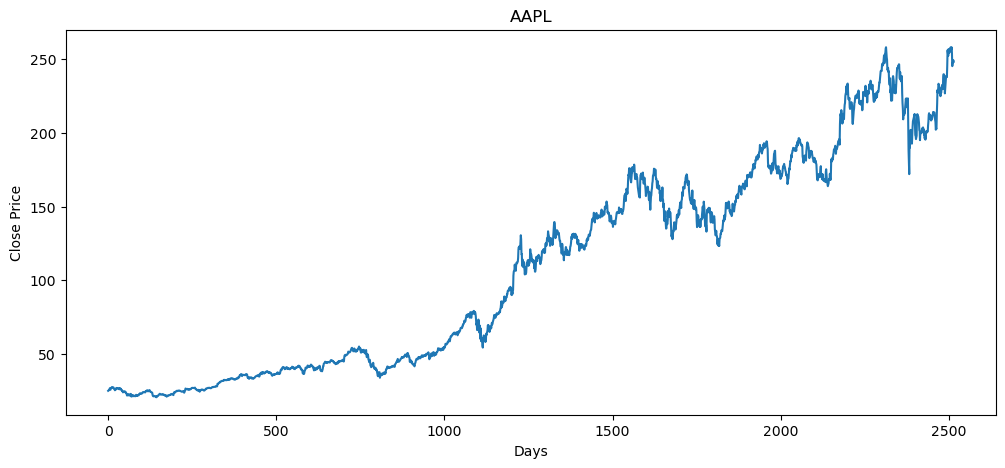

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

3. Feature Engineering


In [14]:
temp_data = [10, 15, 20, 18, 30, 22, 25, 32, 35, 38]
print(sum(temp_data[1:6])/5)

21.0


In [15]:
df1 = pd.DataFrame([10, 15, 20, 18, 30, 22, 25, 32, 35, 38])
df1

,0
0,10
1,15
2,20
3,18
4,30
5,22
6,25
7,32
8,35
9,38


In [16]:
df1['MA_5'] = df1.rolling(5).mean() # moving average with the window size of 5
df1

,0,MA_5
0,10,NaN
1,15,NaN
2,20,NaN
3,18,NaN
4,30,18.6
5,22,21.0
6,25,23.0
7,32,25.4
8,35,28.8
9,38,30.4


100 days moving average


In [17]:
df['MA_100'] = df.Close.rolling(100).mean() #Calculate 100 days moving average on closing price i.e. close column.

In [18]:
df['MA_100'].head(103)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
98           NaN
99     24.143042
100    24.125547
101    24.107092
102    24.088726
Name: MA_100, Length: 103, dtype: float64

Text(0, 0.5, 'Close Price')

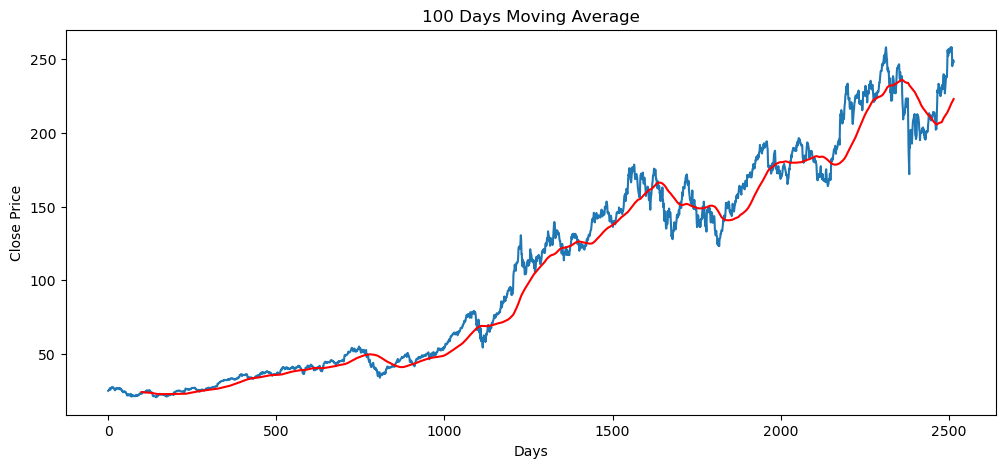

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r') # 'r' for red color
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Close Price')

200 days moving average

In [20]:
df['MA_200']= df.Close.rolling(200).mean()

In [21]:
df['MA_200']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2510    221.884680
2511    221.851145
2512    221.803562
2513    221.759743
2514    221.727364
Name: MA_200, Length: 2515, dtype: float64

Text(0, 0.5, 'Close Price')

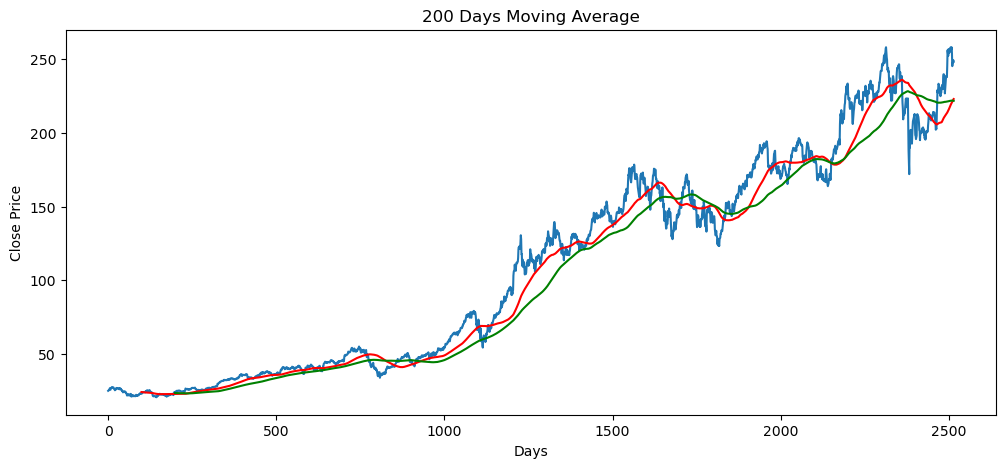

In [22]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title('200 Days Moving Average')
plt.plot(df['MA_100'], 'r') # 'r' for red color
plt.plot(df['MA_200'], 'g') # 'r' for red color
plt.xlabel('Days')
plt.ylabel('Close Price')

Calculating % changed in each trading session


In [23]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
0,24.953529,NaN
1,25.108583,0.006214
2,25.567028,0.018258
3,25.564781,-0.000088
4,25.955803,0.015295
...,...,...
2510,245.270004,-0.034522
2511,247.660004,0.009744
2512,247.770004,0.000444
2513,249.339996,0.006336



4. Data Preprocessing

In [24]:
df.shape

(2515, 8)

# Splitting data into Training and Testing

In [25]:
data_training= pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.70): int(len(df))]) #From 70% to 100% i.e. 30% of the data for testing.

print(data_training)
print(data_testing)

           Close
0      24.953529
1      25.108583
2      25.567028
3      25.564781
4      25.955803
...          ...
1755  143.169983
1756  137.912979
1757  138.237885
1758  136.820221
1759  136.190170

[1760 rows x 1 columns]
           Close
1760  140.767914
1761  136.229568
1762  140.196930
1763  141.516098
1764  141.624405
...          ...
2510  245.270004
2511  247.660004
2512  247.770004
2513  249.339996
2514  248.210007

[755 rows x 1 columns]


In [26]:
data_training

,Close
0,24.953529
1,25.108583
2,25.567028
3,25.564781
4,25.955803
...,...
1755,143.169983
1756,137.912979
1757,138.237885
1758,136.820221


In [27]:
data_testing

,Close
1760,140.767914
1761,136.229568
1762,140.196930
1763,141.516098
1764,141.624405
...,...
2510,245.270004
2511,247.660004
2512,247.770004
2513,249.339996


In [28]:
# Scaling down the data between 0 and 1
# For the LSTM models, we have to scale down the data, we cannot just provide this data as it is,
# we need to kind of normalize the data between 0 and 1

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))


In [30]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02743316],
       [0.02841564],
       [0.03132051],
       ...,
       [0.74524477],
       [0.73626193],
       [0.7322697 ]], shape=(1760, 1))

5. Sequence Creation
   .We create sequence because LSTM Model require the ip data to be in a sequential manner.

In [31]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])
    print(data_training_array[i-100: i])
    
x_train, y_train = np.array(x_train), np.array(y_train)

[[0.02743316]
 [0.02841564]
 [0.03132051]
 [0.03130628]
 [0.03378394]
 [0.03888166]
 [0.03347067]
 [0.0324312 ]
 [0.03915218]
 [0.04094641]
 [0.03947972]
 [0.04187193]
 [0.04385124]
 [0.04303955]
 [0.04223873]
 [0.042439  ]
 [0.04173824]
 [0.03630407]
 [0.03536027]
 [0.03480258]
 [0.029969  ]
 [0.03260029]
 [0.03189955]
 [0.03704766]
 [0.03917846]
 [0.03992205]
 [0.0377055 ]
 [0.03932148]
 [0.03810595]
 [0.03779133]
 [0.03849205]
 [0.03711919]
 [0.03560335]
 [0.03405893]
 [0.03953595]
 [0.03846349]
 [0.03839192]
 [0.03465951]
 [0.03544609]
 [0.03117024]
 [0.03016923]
 [0.02732341]
 [0.02853897]
 [0.02516408]
 [0.02094544]
 [0.02280449]
 [0.02266151]
 [0.02463495]
 [0.02380553]
 [0.0220752 ]
 [0.02482084]
 [0.02279021]
 [0.01984435]
 [0.01997304]
 [0.01619773]
 [0.01332332]
 [0.00724566]
 [0.00797501]
 [0.01022017]
 [0.01226513]
 [0.00858991]
 [0.0116359 ]
 [0.0082181 ]
 [0.00754598]
 [0.00773191]
 [0.00703116]
 [0.014353  ]
 [0.01152151]
 [0.012308  ]
 [0.00291265]
 [0.00387076]
 [0.00

In [32]:
x_train

array([[[0.02743316],
        [0.02841564],
        [0.03132051],
        ...,
        [0.01457923],
        [0.01470864],
        [0.0147805 ]],

       [[0.02841564],
        [0.03132051],
        [0.03130628],
        ...,
        [0.01470864],
        [0.0147805 ],
        [0.01634775]],

       [[0.03132051],
        [0.03130628],
        [0.03378394],
        ...,
        [0.0147805 ],
        [0.01634775],
        [0.01672152]],

       ...,

       [[0.79897146],
        [0.74652131],
        [0.72490585],
        ...,
        [0.78254714],
        [0.77649637],
        [0.74318605]],

       [[0.74652131],
        [0.72490585],
        [0.7264008 ],
        ...,
        [0.77649637],
        [0.74318605],
        [0.74524477]],

       [[0.72490585],
        [0.7264008 ],
        [0.76078636],
        ...,
        [0.74318605],
        [0.74524477],
        [0.73626193]]], shape=(1660, 100, 1))

In [33]:
y_train

array([0.01634775, 0.01672152, 0.01968339, ..., 0.74524477, 0.73626193,
       0.7322697 ], shape=(1660,))

In [34]:
x_train.ndim

3

In [35]:
y_train.ndim

1

6. Model Building

In [36]:
!pip install tensorflow

In [37]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [38]:
#ML Model 
from keras.models import Sequential 
from keras.layers import Dense, LSTM, Input

In [39]:
#This is Sequential LSTM Model in Keras inside tensorflow. It is used for time series prediction.
#It learns from past 100 days stock prices to predict the next day's price.

model = Sequential()

# Input layer defines the shape of the data the model will receive
# (100, 1) means each input sample is a sequence of 100 time steps i.e. 100 previous days stock data/price with 1 feature i.e. Closing Price, 

model.add(Input(shape=(100, 1)))

# First LSTM layer with 128 units i.e. 128 neurons and tanh activation function. Tann means Hyperbolic Tangent, this helps the network handle
# both positive and negative values, which is important when you're trying to capture patterns in sequential data.
# We also set return_sequences=True because we want this layer to return the full sequence to the next LSTM layer.
# For example, if you have a sequence of 100 time steps, and you set return_sequences=True, the LSTM layer will produce 
# an output for each of those 100 steps. And this sequence of op will go inside another LSTM model with 64 units/neurons.
model.add(LSTM(units=128, activation='tanh', return_sequences=True))

# No return_sequences here cause by default return_sequence is flase. Means this layer outputs a single value summarizing the sequence
# Now at this point, we got the single value summarizing the sequence of output that was generated in the previous layer. 
#Now this single op will go to the next layer i.e. Dense layer.
model.add(LSTM(units=64))

# A Dense layer is a fully connected layer, meaning that each neuron in the layer is connected to every neuron in the previous layer. 
# These layers are typically used at the end of a neural network to transform the learned features into the final output.
#Basically the Dense l;ayer will do is it will take single op generated in the previous LSTM Model, analyse it in 25 differenty angles and then 
#it will pass the findings to the next dense layer with 1 neuron.
model.add(Dense(25))

#This final dense layer will take 25op's from the previous dense layer and combines them into a single op i.e. final prediction of stock price.
model.add(Dense(1))

7. Model Training

In [40]:
#So compile() will set the lrarning rules before training starts.
#Optimizer=adam, basicall optimizer is the brain that updates the models internal weights. 
#When our models make wrong predictions, the optimizer adjusts internal weights/ numbers to make bettter guess next time.adam is smart optimizer and is learning speed controller.
#loss = MSE:- This defines the loss function the model will try to minimize.It calculates the average of the squared differences between the predicted and actual values.
#The model repeats this for all the predictions and finds the average error.
#Basicall we use adam to learn and measure how wrong we are using MSE.
model.compile(optimizer='adam', loss='mean_squared_error')
#x_train= in's i.e. what you feed in --> previous 100 days windows i.e. stock prices.
#y_train= o/p--> What do yopu want the model to predict --> next day's price.
#epochs=50. One epoch=one complete pass through your training data. Here we trianed opur model 50 times to improve accuracy.
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0090
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 6.1643e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 5.8423e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.5062e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.7760e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 6.0790e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 5.5265e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.3093e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 5.7571e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 4.5863e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 4.4087e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 3.8138e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 3.7116e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 3.9541e-04
Epoch 15/50
52/52 ━

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [42]:
# Save the trained model.
model.save('stock_prediction_model.keras')

8. Preparing Test Data

In [43]:
data_testing

,Close
1760,140.767914
1761,136.229568
1762,140.196930
1763,141.516098
1764,141.624405
...,...
2510,245.270004
2511,247.660004
2512,247.770004
2513,249.339996


In [44]:
data_training.tail(100) #inorder to predict the price of 1st test data starting from 1759 we want previous 100 days data and that data is in data_training so that's why we take last 100 data fromm training data.

,Close
1660,135.263947
1661,140.690643
1662,137.987137
1663,138.144424
1664,141.349289
...,...
1755,143.169983
1756,137.912979
1757,138.237885
1758,136.820221


In [45]:
past_100_days = data_training.tail(100)
past_100_days

,Close
1660,135.263947
1661,140.690643
1662,137.987137
1663,138.144424
1664,141.349289
...,...
1755,143.169983
1756,137.912979
1757,138.237885
1758,136.820221


In [46]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [47]:
input_data = scaler.fit_transform(final_df)

In [48]:
input_data

array([[8.88770191e-02],
       [1.29127726e-01],
       [1.09075372e-01],
       [1.10242000e-01],
       [1.34013010e-01],
       [1.76742972e-01],
       [1.70909379e-01],
       [1.69961635e-01],
       [1.88190708e-01],
       [1.45679970e-01],
       [1.51221567e-01],
       [1.69961635e-01],
       [1.64492584e-01],
       [1.25700389e-01],
       [8.55229067e-02],
       [4.72410258e-02],
       [5.36575936e-02],
       [7.31267473e-02],
       [3.39698953e-02],
       [4.49077695e-02],
       [7.63350878e-02],
       [7.25434332e-02],
       [9.38354150e-02],
       [1.18554622e-01],
       [1.18554622e-01],
       [8.77832770e-02],
       [1.00835410e-01],
       [8.25333373e-02],
       [9.86479258e-02],
       [1.17825536e-01],
       [1.27741988e-01],
       [1.52752738e-01],
       [1.57784473e-01],
       [1.41960975e-01],
       [1.49179855e-01],
       [1.46482169e-01],
       [1.68211579e-01],
       [1.80607626e-01],
       [1.58003244e-01],
       [1.86659650e-01],


In [49]:
input_data.shape

(855, 1)

In [50]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [51]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(755, 100, 1)
(755,)


In [52]:
x_test.ndim

3

In [57]:
y_test.ndim

1

In [60]:
y_predicted = model.predict(x_test)
y_predicted.shape

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


(755, 1)

In [61]:
y_test

array([1.29700855e-01, 9.60391968e-02, 1.25465773e-01, 1.35250261e-01,
       1.36053591e-01, 1.32621839e-01, 1.60953088e-01, 1.76871315e-01,
       1.97973612e-01, 1.76140984e-01, 1.42917094e-01, 2.22799997e-01,
       2.05275337e-01, 1.85633475e-01, 1.44596754e-01, 9.96900592e-02,
       9.77152344e-02, 1.01664884e-01, 1.05906757e-01, 7.20433042e-02,
       1.59811359e-01, 1.80509954e-01, 1.70123930e-01, 1.82996791e-01,
       1.73854130e-01, 1.87970353e-01, 1.92139113e-01, 1.68149219e-01,
       1.84020703e-01, 1.90530303e-01, 1.68880795e-01, 1.40429238e-01,
       1.18121267e-01, 1.68295557e-01, 1.70343381e-01, 1.66686293e-01,
       1.58055871e-01, 1.30847790e-01, 1.16439231e-01, 1.28946191e-01,
       1.25362216e-01, 1.42403837e-01, 1.49571673e-01, 1.33041952e-01,
       8.39647995e-02, 6.94099027e-02, 5.37580948e-02, 5.32464217e-02,
       7.62851767e-02, 5.27342960e-02, 5.00277821e-02, 3.66433615e-02,
       7.46034237e-03, 3.35713992e-02, 3.59117856e-02, 3.65731352e-04,
      

In [62]:
#Now we want to compare the y_predicted to y_test to see the difference, but we cannot do that directly as because it is the scaled data.
#In-order to see the difference we will reverse the scaling i.e. we will do inverse transform i.e. revert scaled data.
#Inverse transform is the process of reverting scaled data to the original data.

y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [64]:
y_predicted

array([137.46812 , 138.13097 , 137.70914 , 138.33885 , 139.47505 ,
       140.42857 , 140.87343 , 142.24104 , 144.1117  , 146.45168 ,
       147.13931 , 145.66139 , 147.69443 , 149.15494 , 149.08627 ,
       146.79778 , 142.80017 , 139.64836 , 137.89687 , 137.27171 ,
       135.80707 , 138.16295 , 141.83105 , 144.27087 , 146.12202 ,
       146.7394  , 147.42001 , 148.04045 , 147.327   , 147.2329  ,
       147.61873 , 147.03125 , 145.1507  , 142.62631 , 142.93634 ,
       144.00575 , 144.80258 , 144.8923  , 143.56883 , 141.69162 ,
       140.80075 , 140.3039  , 140.80531 , 141.73618 , 141.77908 ,
       139.4926  , 136.73454 , 134.08508 , 132.2583  , 132.11208 ,
       131.59715 , 131.02602 , 130.09341 , 128.22528 , 127.579865,
       127.57706 , 126.44879 , 125.63105 , 124.78386 , 125.37639 ,
       126.41309 , 127.44688 , 128.94327 , 130.12814 , 131.24258 ,
       132.33934 , 132.88678 , 133.11879 , 133.94366 , 135.65967 ,
       137.5549  , 138.71394 , 139.94548 , 141.42043 , 141.564

In [65]:
y_test

array([140.76791382, 136.22956848, 140.19692993, 141.51609802,
       141.62440491, 141.16172791, 144.98141479, 147.12754822,
       149.97261047, 147.02908325, 142.54975891, 153.31976318,
       150.95704651, 148.30888367, 142.7762146 , 136.7217865 ,
       136.45553589, 136.98803711, 137.55993652, 132.99438477,
       144.82748413, 147.61811829, 146.21784973, 147.95339966,
       146.72076416, 148.62394714, 149.18598938, 145.95161438,
       148.09144592, 148.96908569, 146.05024719, 142.21434021,
       139.20672607, 145.97134399, 146.24743652, 145.75437927,
       144.59080505, 140.92254639, 138.97994995, 140.66616821,
       140.18296814, 142.4805603 , 143.44694519, 141.21836853,
       134.60166931, 132.63934326, 130.52912903, 130.46014404,
       133.56628418, 130.39109802, 130.02619934, 128.22167969,
       124.28715515, 127.80751038, 128.12304688, 123.3306427 ,
       124.60270691, 123.28133392, 127.81734467, 128.33999634,
       128.91194153, 131.63354492, 131.55467224, 132.88

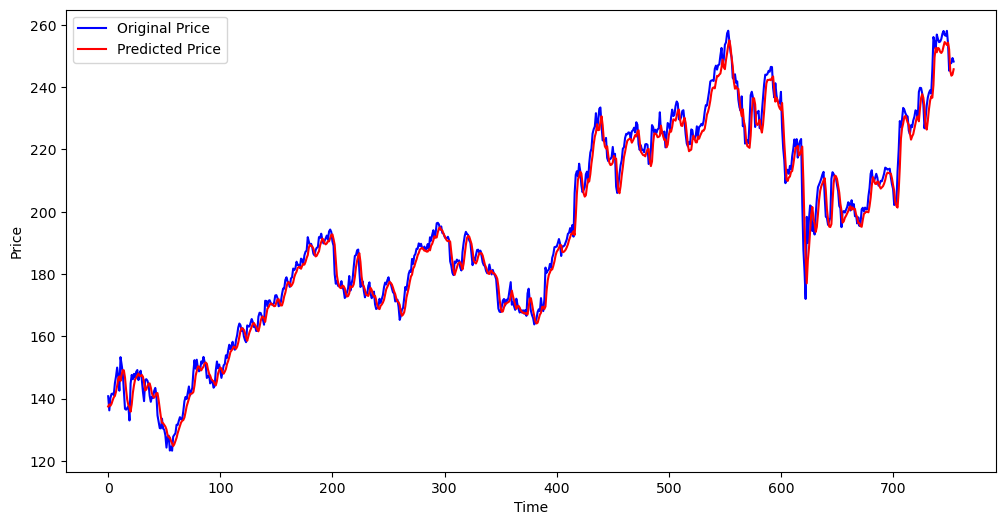

In [66]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
# plt.xlim(500, 700)
# plt.ylim(10, 25)
plt.show()

In [70]:
# MSE
mse = np.mean((y_test - y_predicted) ** 2)
mse


np.float64(16.731546225857578)

In [71]:
# RMSE
rmse = np.sqrt(mse)
rmse

np.float64(4.090421277308436)

In [69]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.090421277308436


In [72]:
# R-Squared
# Calculate SSR (Sum of Squared Residuals)
ssr = np.sum((y_test - y_predicted) ** 2)

# Calculate SST (Total Sum of Squares)
sst = np.sum((y_test - np.mean(y_test)) ** 2)

# Calculate R^2
r_squared = 1 - (ssr / sst)
r_squared

np.float64(0.983950850464422)

In [73]:
from sklearn.metrics import mean_squared_error, r2_score

In [74]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 16.731546225857578


In [75]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.090421277308436


In [76]:
r2 = r2_score(y_test, y_predicted)
print(f"R-squared (R²): {r2}")

R-squared (R²): 0.983950850464422
